In [1]:
import numpy as np
from scipy.fftpack import fft, ifft 

In [2]:
def bspline_python(p, j, x):
    """Return the value at x in [0,1[ of the B-spline with 
    integer nodes of degree p with support starting at j.
    Implemented recursively using the de Boor's recursion formula"""
    assert (x >= 0.0) & (x <= 1.0)
    assert (type(p) == int) & (type(j) == int)
    if p == 0:
        if j == 0:
            return 1.0
        else:
            return 0.0
    else:
        w = (x - j) / p
        w1 = (x - j - 1) / p
    return w * bspline_python(p - 1, j, x) + (1 - w1) * bspline_python(p - 1, j + 1, x)

In [3]:
class Advection:
    
    """ Class to compute BSL advection of 1d function """
    
    def __init__(self, p, xmin, xmax, ncells, bspline):
        assert p & 1 == 1  # check that p is odd
        self.p = p
        self.ncells = ncells
        # compute eigenvalues of degree p b-spline matrix
        self.modes = 2 * np.pi * np.arange(ncells) / ncells
        self.deltax = (xmax - xmin) / ncells
        self.bspline = bspline
        self.eig_bspl = bspline(p, -(p + 1) // 2, 0.0)
        for j in range(1, (p + 1) // 2):
            self.eig_bspl += bspline(p, j - (p + 1) // 2, 0.0) * 2 * np.cos(j * self.modes)
            
        self.eigalpha = np.zeros(ncells, dtype=complex)
    
    def __call__(self, f, alpha):
        """compute the interpolating spline of degree p of odd degree 
        of a function f on a periodic uniform mesh, at
        all points xi-alpha"""
        p = self.p
        assert (np.size(f) == self.ncells)
        # compute eigenvalues of cubic splines evaluated at displaced points
        ishift = np.floor(-alpha / self.deltax)
        beta = -ishift - alpha / self.deltax
        self.eigalpha.fill(0.)
        for j in range(-(p-1)//2, (p+1)//2 + 1):
            self.eigalpha += self.bspline(p, j-(p+1)//2, beta) * np.exp((ishift+j)*1j*self.modes)
            
        # compute interpolating spline using fft and properties of circulant matrices
        return np.real(ifft(fft(f) * self.eigalpha / self.eig_bspl))

In [4]:
def interpolation_test(bspline):
    """ Test to check interpolation"""
    n = 64
    cs = Advection(3,0,1,n, bspline)
    x = np.linspace(0,1,n, endpoint=False)
    f = np.sin(x*4*np.pi)
    alpha = 0.2
    return np.allclose(np.sin((x-alpha)*4*np.pi), cs(f, alpha))
    

interpolation_test(bspline_python)

True

In [6]:
from numba import jit,  int32, float64
from scipy.fftpack import fft, ifft

@jit("float64(int32,int32,float64)",nopython=True)
def bspline_numba(p, j, x):
    
        """Return the value at x in [0,1[ of the B-spline with 
        integer nodes of degree p with support starting at j.
        Implemented recursively using the de Boor's recursion formula"""
        
        assert ((x >= 0.0) & (x <= 1.0))
        if p == 0:
            if j == 0:
                return 1.0
            else:
                return 0.0
        else:
            w = (x-j)/p
            w1 = (x-j-1)/p
        return w * bspline_numba(p-1,j,x)+(1-w1)*bspline_numba(p-1,j+1,x)

interpolation_test(bspline_numba)

True

In [7]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (11,7)

In [8]:
from tqdm.notebook import tqdm
from collections import defaultdict

Mrange = (2 ** np.arange(6, 12)).astype(int)
opts = [bspline_numba]

times = defaultdict(list)
for M in tqdm(Mrange):
    x = np.linspace(0, 1, M, endpoint=False)
    for opt in opts:
        f = np.sin(x*4*np.pi)
        cs = Advection(5, 0, 1, M, opt)
    
        alpha = 0.1
        ts = %timeit -q -n 100 -o cs(f, alpha)
        times[opt.__name__].append(ts.best)

  0%|          | 0/6 [00:00<?, ?it/s]

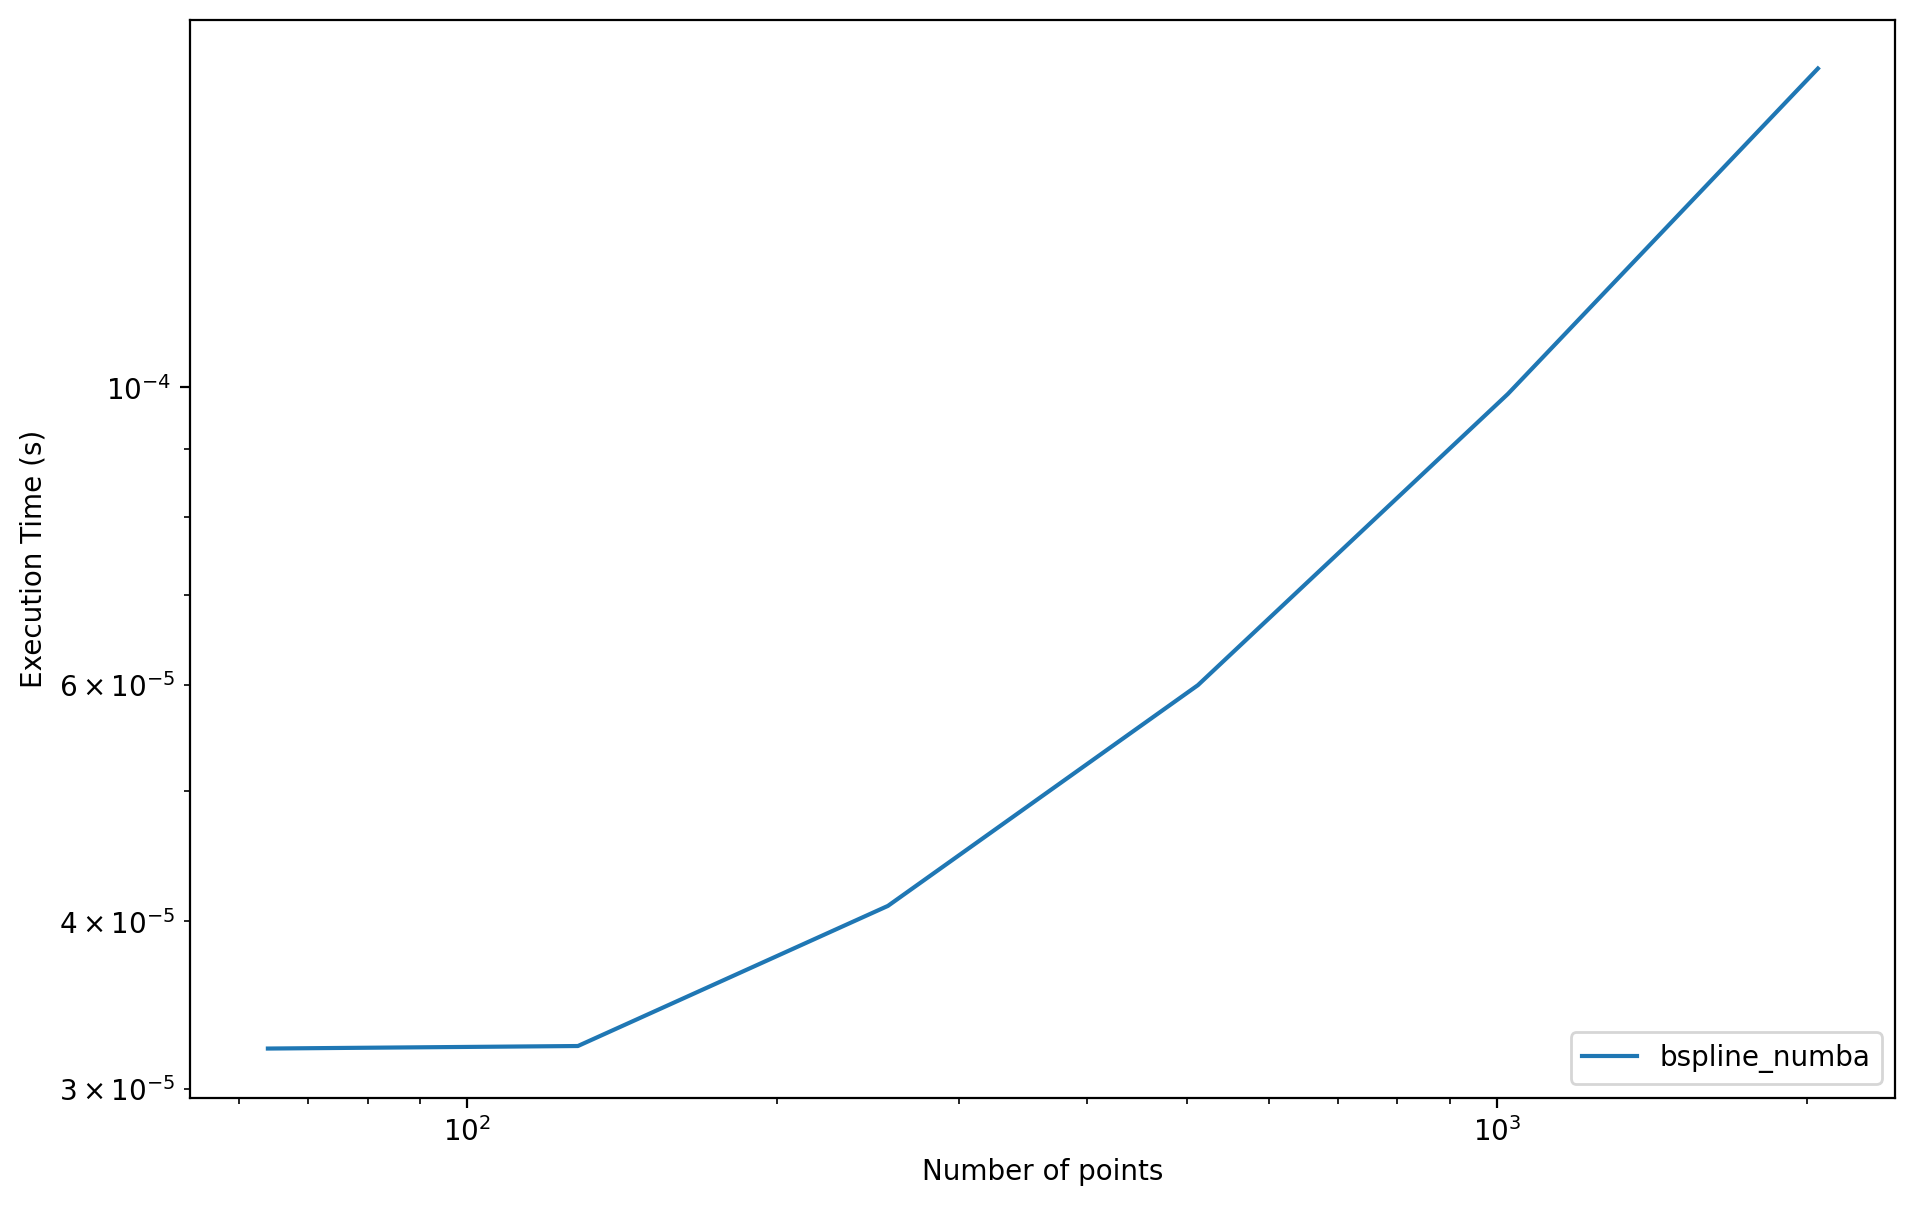

In [9]:
for o, t in times.items():
    plt.loglog(Mrange, t, label=o)
    
plt.legend(loc='lower right')
plt.xlabel('Number of points')
plt.ylabel('Execution Time (s)');

In [26]:
class VlasovPoisson:
    
    def __init__(self, xmin, xmax, nx, vmin, vmax, nv, p = 3, opt=None):
        
        # Grid
        self.nx = nx
        self.x, self.dx = np.linspace(xmin, xmax, nx, endpoint=False, retstep=True)
        self.nv = nv
        self.v, self.dv = np.linspace(vmin, vmax, nv, endpoint=False, retstep=True)
        
        # Distribution function
        self.f = np.zeros((nx,nv))
        
        self.p = p
        
        if opt :
            # Interpolators for advection
            self.cs_x = Advection(p, xmin, xmax, nx, opt)
            self.cs_v = Advection(p, vmin, vmax, nv, opt)
            
        # Modes for Poisson equation
        self.modes = np.zeros(nx)
        k =  2* np.pi / (xmax - xmin)
        self.modes[:nx//2] = k * np.arange(nx//2)
        self.modes[nx//2:] = - k * np.arange(nx//2,0,-1)
        self.modes += self.modes == 0 # avoid division by zero 
        
    def advection_x(self, dt):
        for j in range(self.nv):
            alpha = dt * self.v[j]
            self.f[j,:] = self.cs_x(self.f[j,:], alpha)
            
    def advection_v(self, e, dt):
        for i in range(self.nx):
            alpha = dt * e[i] 
            self.f[:,i] = self.cs_v(self.f[:,i], alpha)
            
    def compute_rho(self):
        rho = self.dv * np.sum(self.f, axis=0)
        return  rho - rho.mean()
            
    def compute_e(self, rho):
        # compute Ex using that ik*Ex = rho
        rhok = fft(rho)/self.modes
        return np.real(ifft(-1j*rhok))
    
    def run(self, f, nstep, dt):
        self.f = f
        nrj = []
        self.advection_x(0.5*dt)
        for istep in tqdm(range(nstep)):
            rho = self.compute_rho()
            e = self.compute_e(rho)
            self.advection_v(e, dt)
            self.advection_x(dt)
            # nrj.append(0.5*np.log(np.sum(e*e)*self.dx))
            nrj.append((np.sum(e*e)*self.dx)**0.5)
                
        return nrj

  0%|          | 0/600 [00:00<?, ?it/s]

 bspline_numba : 1.1810 


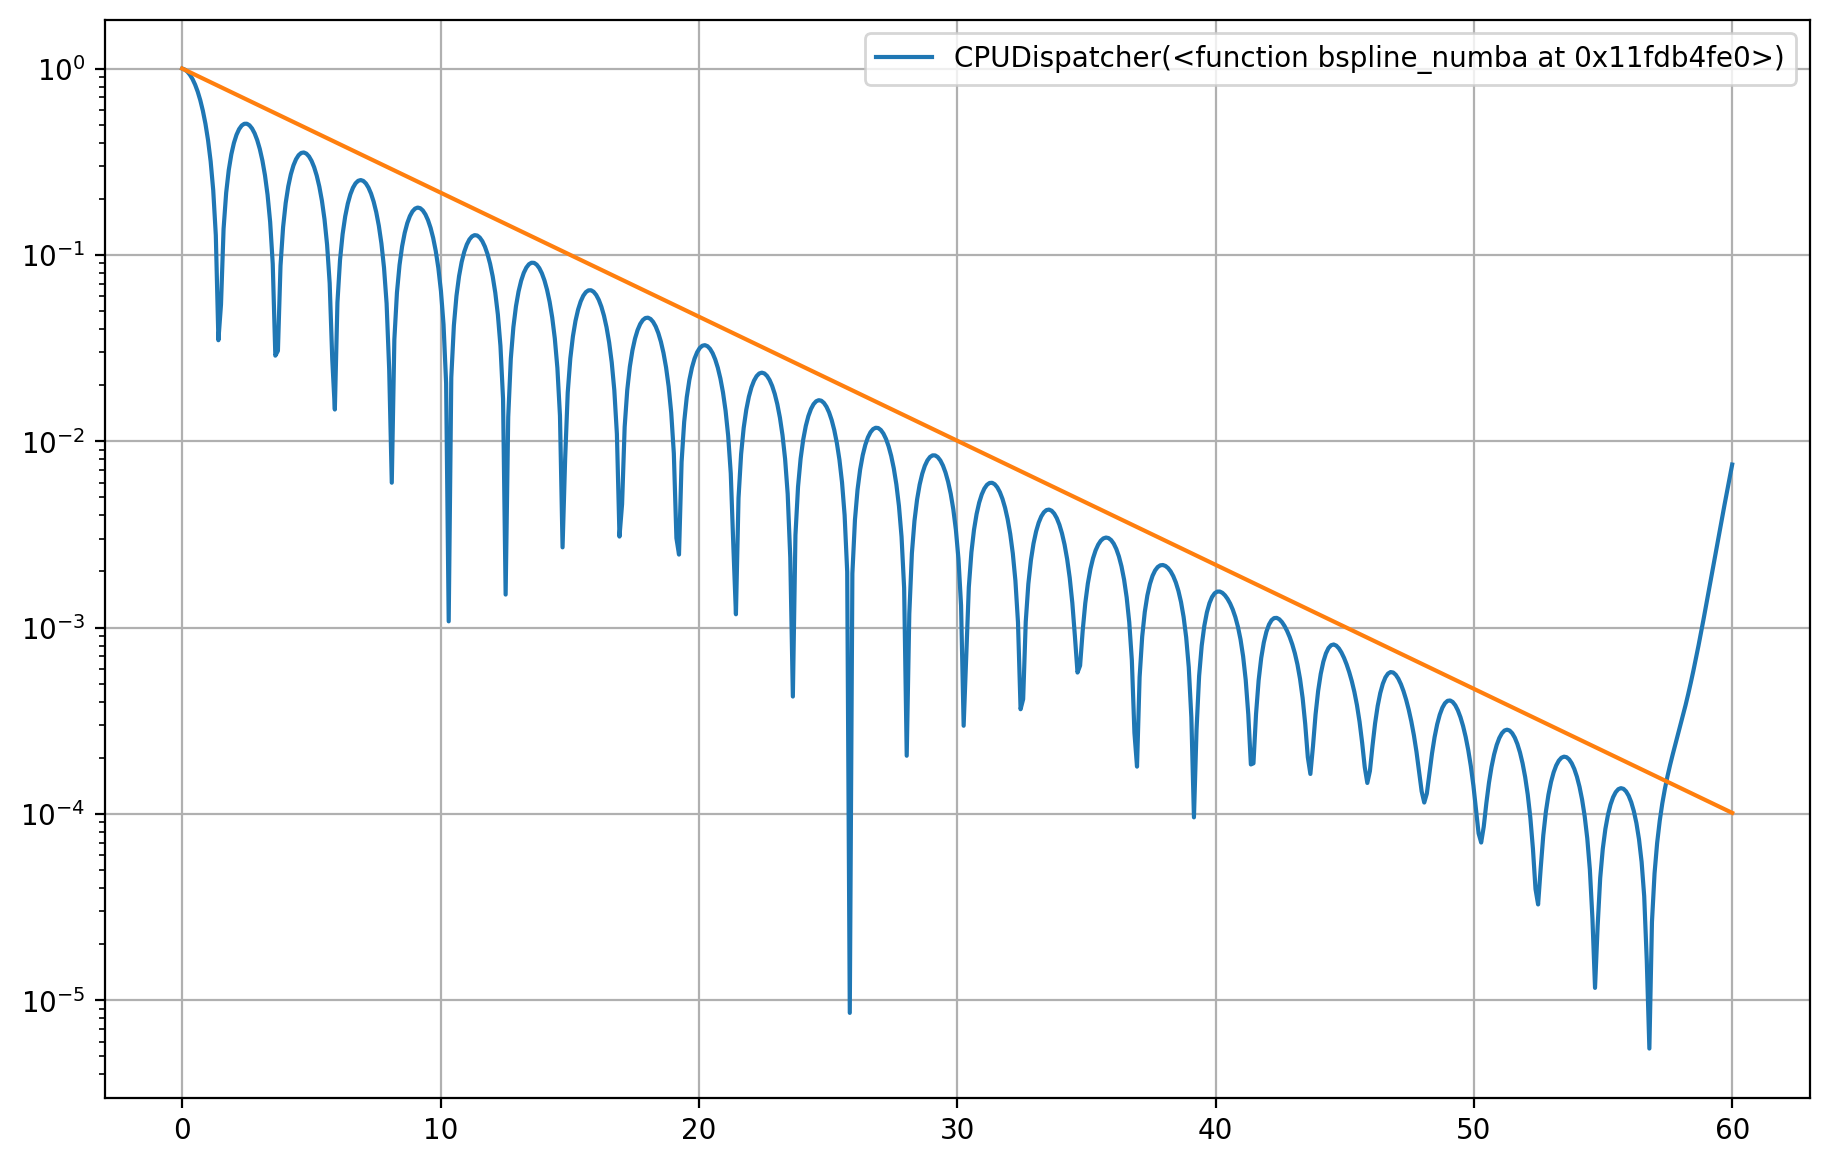

In [27]:
from time import time

elapsed_time = {}
fig, axes = plt.subplots()
nrj = []
for opt in opts:
    
    # Set grid
    nx, nv = 32, 64
    xmin, xmax = 0.0, 4*np.pi
    vmin, vmax = -6., 6.
    
    # Create Vlasov-Poisson simulation
    sim = VlasovPoisson(xmin, xmax, nx, vmin, vmax, nv, opt=opt)

    # Initialize distribution function
    X, V = np.meshgrid(sim.x, sim.v)
    eps, kx = 0.001, 0.5
    f = (1.0+eps*np.cos(kx*X))/np.sqrt(2.0*np.pi)* np.exp(-0.5*V*V)

    # Set time domain
    nstep = 600
    t, dt = np.linspace(0.0, 60.0, nstep, retstep=True)
    
    # Run simulation
    etime = time()
    nrj.append(sim.run(f, nstep, dt))
    print(" {0:12s} : {1:.4f} ".format(opt.__name__, time()-etime))
    
    # # Plot energy
    # axes.plot(t, nrj, label=opt)

nrj = np.array(nrj).flatten()
# Plot (normalized) energy
axes.plot(t, nrj/nrj[0], label=opt)
axes.plot(t, np.exp(-0.1533*t))#-5.50)
axes.set_yscale('log')
axes.grid()
plt.legend();

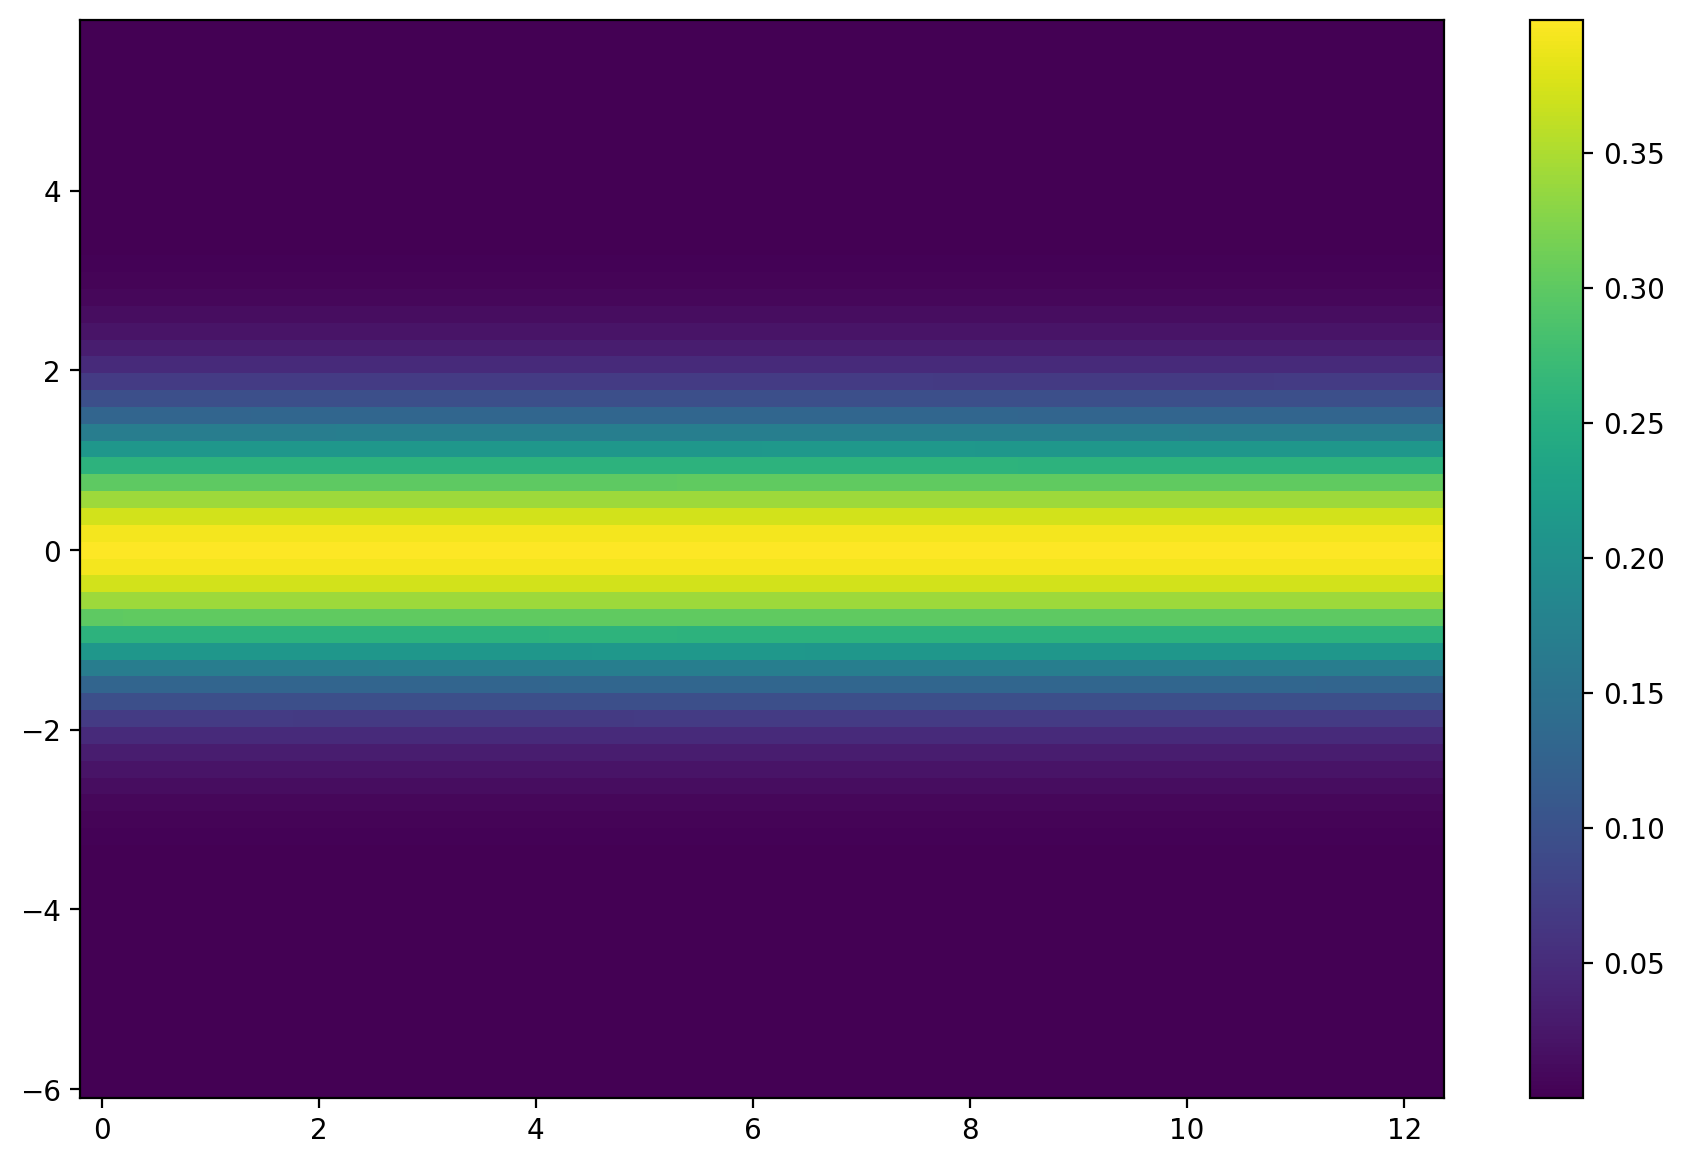

In [25]:
# Plot f
V, X = np.meshgrid(sim.v, sim.x)
plt.pcolormesh(X, V, sim.f.T, shading='auto')
plt.colorbar()